In [8]:
from tensorflow.keras.datasets import cifar10

# Chargement des données
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Train :", x_train.shape)
print("Test :", x_test.shape)

Train : (50000, 32, 32, 3)
Test : (10000, 32, 32, 3)


Afficher quelques images

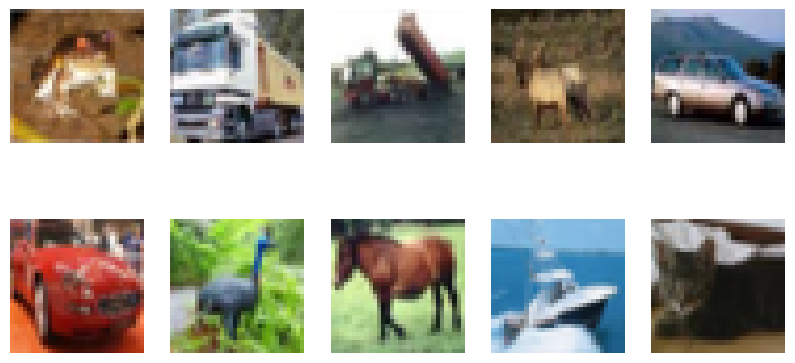

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.axis("off")

plt.show()

# Data pre-processing 

In [10]:
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

In [21]:
import numpy as np

noise_factor = 0.2

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

# Garder les valeurs entre 0 et 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

In [12]:
# Configurations principales de nos modèles
IMG_SIZE          = 32                # taille coté final d'une image en pixel (ici 28x28)
NB_EPOCHS_DENOISE = 100               # nombre epoch alogithme debruiter
BATCH_SIZE        = 128               # taille batch de traitement
SAV_MODEL_DENOISE = "denoiser.h5"     # sauvegarde du modele de debruitage

###### Encodeur

In [13]:
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D


# The encoding process
input_img =\
 Input(shape=(IMG_SIZE, IMG_SIZE, 3))  #SOLUTION

# Encoding #

# Conv1 #
x = Conv2D(\
           filters = 32, kernel_size = (3, 3), activation='relu', padding='same')(input_img)#SOLUTION
# kernel_size: Specifying the height and width of the 2D convolution window.
x = MaxPooling2D(\
                 pool_size = (2, 2), padding='same')(x)#SOLUTION

# Conv 2 #
x = Conv2D(\
           filters = 32,kernel_size = (3, 3), activation='relu', padding='same')(x)#SOLUTION
encoded = MaxPooling2D(\
                       pool_size = (2, 2), padding='same')(x)#SOLUTION

###### Decodeur

In [16]:
# Decoding #

# DeConv1
x = Conv2D(\
           32, (3, 3), activation='relu', padding='same')(encoded)#SOLUTION
x = UpSampling2D(\
                 (2, 2))(x)#SOLUTION

# DeConv2
x = Conv2D(\
           32, (3, 3), activation='relu', padding='same')(x) #SOLUTION
x = UpSampling2D(\
                 (2, 2))(x)#SOLUTION

# Deconv3
decoded = Conv2D(3, (3, 3), activation=\
                 'sigmoid', padding='same')(x)#SOLUTION

###### Auto-encodeur

In [23]:
from tensorflow.keras.models import Model
# Declare the model
autoencoder = \
Model(input_img, decoded)#SOLUTION
autoencoder.compile(optimizer=\
                    'adadelta',#SOLUTION
                    loss=\
                    'mse')#SOLUTION
autoencoder.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 8, 8, 32)          0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 8, 8, 32)          9248

In [24]:
import tensorflow as tf 

# Train the model
history = autoencoder.fit(\
                          x_train_noisy, x_train,#SOLUTION
                epochs=\
                NB_EPOCHS_DENOISE,#SOLUTION
                batch_size=\
                BATCH_SIZE,#SOLUTION
                shuffle=\
                True,#SOLUTION
                validation_data=(\
                                 x_test_noisy, x_test),#SOLUTION
                callbacks=[tf.keras.callbacks.TensorBoard(log_dir='/tmp/tb', histogram_freq=0, write_graph=False)]
               )

Epoch 1/100
391/391 [==============================] - 29s 72ms/step - loss: 0.0646 - val_loss: 0.0641
Epoch 2/100
391/391 [==============================] - 31s 79ms/step - loss: 0.0642 - val_loss: 0.0638
Epoch 3/100
391/391 [==============================] - 33s 83ms/step - loss: 0.0640 - val_loss: 0.0636
Epoch 4/100
391/391 [==============================] - 33s 85ms/step - loss: 0.0639 - val_loss: 0.0635
Epoch 5/100
391/391 [==============================] - 36s 91ms/step - loss: 0.0637 - val_loss: 0.0634
Epoch 6/100
391/391 [==============================] - 33s 83ms/step - loss: 0.0636 - val_loss: 0.0632
Epoch 7/100
391/391 [==============================] - 32s 81ms/step - loss: 0.0635 - val_loss: 0.0631
Epoch 8/100
391/391 [==============================] - 30s 78ms/step - loss: 0.0634 - val_loss: 0.0630
Epoch 9/100
391/391 [==============================] - 30s 78ms/step - loss: 0.0633 - val_loss: 0.0629
Epoch 10/100
391/391 [==============================] - 29s 74ms/step - l

In [25]:
# save the model
autoencoder.save("model_denoising.h5") #SOLUTION

c:\Users\gbencheikh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


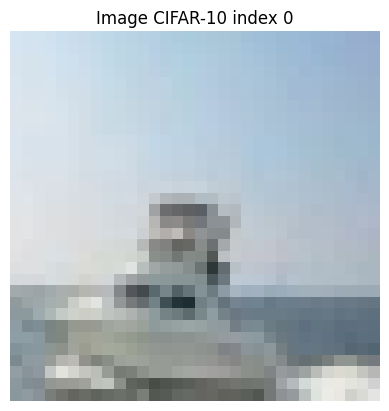

In [54]:
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

img = x_train[100]

plt.imshow(img)
plt.axis("off")
plt.title("Image CIFAR-10 index 0")
plt.show()

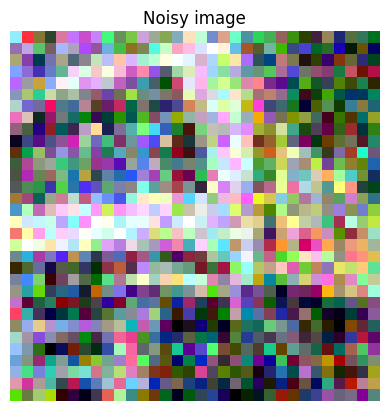

In [42]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 1. normalisation correcte
img = x_train[1].astype("float32") / 255.0

# 2. ajout bruit
noise_factor = 0.2

noisy_img = img + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=img.shape
)

# 3. IMPORTANT : clip dans [0,1]
noisy_img = np.clip(noisy_img, 0.0, 1.0)

# 4. affichage
plt.imshow(noisy_img)
plt.axis("off")
plt.title("Noisy image")
plt.show()


In [43]:
from PIL import Image 

noisy_img_uint8 = (noisy_img * 255).astype(np.uint8)

noisy_pil = Image.fromarray(noisy_img_uint8)

noisy_pil.save("image_bruitee.png")